# I-JEPA from scratch — predict the *representation*, not the pixels

A small, faithful, single-GPU implementation of **I-JEPA** (Assran et al., CVPR 2023)
on **CIFAR-10**. The whole idea in one line:

> hide part of an image, and predict the **embedding** of the hidden part from the
> visible part — never reconstruct a pixel.

**What's in here**
1. Data — CIFAR-10
2. The encoder — a small Vision Transformer
3. Masking — I-JEPA's multi-block scheme
4. The predictor — a narrow ViT
5. Putting it together — context encoder, EMA target encoder, predictor, latent loss
6. Train
7. Evaluate — a linear probe on the frozen encoder vs. a raw-pixel baseline
8. What we learned

The three networks and the deliberate asymmetry (an EMA "teacher" with a stop-gradient)
are the whole trick. By the end the linear probe on our frozen features beats a raw-pixel
linear probe by a wide margin — evidence the encoder learned *semantics*, not pixels.

In [1]:
import math, copy, time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- config (small enough for a single GPU / a few minutes) ---
IMG, PATCH = 32, 4               # CIFAR is 32x32; 4x4 patches -> an 8x8 grid
GH = GW = IMG // PATCH           # 8 x 8
N = GH * GW                      # 64 patch tokens
DIM, DEPTH, HEADS = 192, 6, 3    # context/target encoder (a small ViT)
PDIM, PDEPTH = 96, 4             # the predictor is deliberately NARROWER
EMA_M = 0.996                    # how slowly the teacher trails the student
EPOCHS = 40
print("device:", DEVICE)

device: cuda


## 1. Data — CIFAR-10

CIFAR-10 is 60,000 32×32 colour images in 10 classes, downloaded automatically by
torchvision. JEPA is **self-supervised**: we never look at the labels during
pretraining — they're only used at the very end to *measure* what the encoder learned.

In [2]:
norm = T.Normalize((.4914,.4822,.4465), (.247,.243,.261))
tf = T.Compose([T.ToTensor(), norm])
train_set = tv.datasets.CIFAR10("data", train=True,  download=True, transform=tf)
test_set  = tv.datasets.CIFAR10("data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, 256, shuffle=True, num_workers=4, drop_last=True, pin_memory=True)
print(len(train_set), "train images,", len(test_set), "test images")

50000 train images, 10000 test images


## 2. The encoder — a small Vision Transformer

A ViT cuts the image into patches, linearly embeds each into a vector, adds a learned
position embedding, and runs a stack of Transformer blocks. The same architecture is
used for **both** encoders (the trained "student" and the EMA "teacher").

The one twist I-JEPA needs: the encoder can run on a **subset** of patch tokens
(`keep_idx`) — that's how the context encoder sees only the *visible* patches.

In [3]:
class Block(nn.Module):
    # standard pre-norm Transformer block: attention + MLP, both with residuals
    def __init__(self, dim, heads):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim))
    def forward(self, x):
        y = self.n1(x); x = x + self.attn(y, y, y, need_weights=False)[0]
        return x + self.mlp(self.n2(x))

class ViTEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch = nn.Conv2d(3, DIM, PATCH, PATCH)               # patchify + linear embed
        self.pos = nn.Parameter(torch.zeros(1, N, DIM)); nn.init.trunc_normal_(self.pos, std=.02)
        self.blocks = nn.ModuleList([Block(DIM, HEADS) for _ in range(DEPTH)])
        self.norm = nn.LayerNorm(DIM)
    def forward(self, img, keep_idx=None):
        x = self.patch(img).flatten(2).transpose(1, 2)             # B, N, DIM
        x = x + self.pos
        if keep_idx is not None:                                   # context encoder: visible tokens only
            x = x[:, keep_idx]
        for b in self.blocks: x = b(x)
        return self.norm(x)

## 3. Masking — I-JEPA's multi-block scheme

I-JEPA samples **4 target blocks** (each 15–20% of the image, aspect 0.75–1.5) and one
large **context block** (85–100%), then removes the overlap so the task isn't trivial.

We use a small simplification that's easier to read and works just as well at this scale:
sample the 4 target blocks on the 8×8 grid, and let the **context be everything that
isn't a target**. One mask is shared across the batch (as in I-JEPA's mask collator).

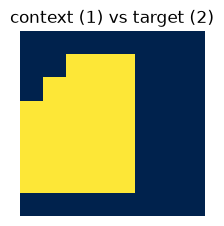

In [4]:
def sample_mask(n_blocks=4, scale=(0.15, 0.2), aspect=(0.75, 1.5)):
    # returns (ctx_idx, tgt_idx) on the GH x GW grid; context = complement of targets
    tgt = torch.zeros(GH, GW, dtype=torch.bool)
    for _ in range(n_blocks):
        s = (scale[0] + torch.rand(1).item()*(scale[1]-scale[0])) * N
        ar = aspect[0] + torch.rand(1).item()*(aspect[1]-aspect[0])
        h = max(1, min(GH, round(math.sqrt(s*ar)))); w = max(1, min(GW, round(math.sqrt(s/ar))))
        top = torch.randint(0, GH-h+1, (1,)).item(); left = torch.randint(0, GW-w+1, (1,)).item()
        tgt[top:top+h, left:left+w] = True
    tgt = tgt.flatten()
    if tgt.all(): tgt[0] = False
    if not tgt.any(): tgt[N-1] = True
    idx = torch.arange(N)
    return idx[~tgt].to(DEVICE), idx[tgt].to(DEVICE)

# visualize one sampled mask: cyan = context (visible), violet = target (predicted)
ci, ti = sample_mask()
grid = torch.zeros(N); grid[ci.cpu()] = 1; grid[ti.cpu()] = 2
plt.figure(figsize=(2.4,2.4))
plt.imshow(grid.reshape(GH, GW), cmap="cividis"); plt.title("context (1) vs target (2)"); plt.axis("off"); plt.show()

## 4. The predictor — a narrow ViT

The predictor takes the context encoder's outputs, plus a learned **mask token** placed
at each target position (with that position's embedding), and predicts the target
embeddings. It's deliberately narrower than the encoder — its job is only to *predict*,
not to be the representation we keep.

In [5]:
class Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(DIM, PDIM)                          # encoder dim -> predictor dim
        self.pos = nn.Parameter(torch.zeros(1, N, PDIM)); nn.init.trunc_normal_(self.pos, std=.02)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, PDIM)); nn.init.trunc_normal_(self.mask_token, std=.02)
        self.blocks = nn.ModuleList([Block(PDIM, HEADS) for _ in range(PDEPTH)])
        self.norm = nn.LayerNorm(PDIM)
        self.out = nn.Linear(PDIM, DIM)                            # back to encoder dim
    def forward(self, ctx_repr, ctx_idx, tgt_idx):
        B = ctx_repr.size(0)
        x = self.embed(ctx_repr) + self.pos[:, ctx_idx]            # context tokens
        m = (self.mask_token + self.pos[:, tgt_idx]).expand(B, -1, -1)   # mask tokens at targets
        x = torch.cat([x, m], dim=1)
        for b in self.blocks: x = b(x)
        x = self.norm(x)[:, ctx_repr.size(1):]                     # keep the mask-token outputs
        return self.out(x)

## 5. Putting it together

- **Context encoder** (student): encodes the visible patches — trained by gradient descent.
- **Target encoder** (teacher): an **exponential moving average** of the student, with a
  **stop-gradient**. It encodes the *full* image; its outputs at the target positions are
  the prediction targets.
- **Predictor**: predicts those target embeddings from the context.
- **Loss**: smooth-L1 between predicted and target embeddings — entirely in latent space.

The EMA + stop-gradient asymmetry is what stops the model from cheating by making every
embedding identical (representation collapse).

In [6]:
class IJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.context = ViTEncoder()
        self.target = copy.deepcopy(self.context)                  # teacher starts as a copy
        for p in self.target.parameters(): p.requires_grad_(False) # ...and never gets gradients
        self.predictor = Predictor()
    @torch.no_grad()
    def ema_update(self, m=EMA_M):
        for pt, pc in zip(self.target.parameters(), self.context.parameters()):
            pt.mul_(m).add_(pc, alpha=1-m)
    def forward(self, img):
        ctx_idx, tgt_idx = sample_mask()
        ctx_repr = self.context(img, keep_idx=ctx_idx)             # encode visible context only
        pred = self.predictor(ctx_repr, ctx_idx, tgt_idx)
        with torch.no_grad():
            tgt = self.target(img)[:, tgt_idx]                     # teacher targets (stop-grad)
        return F.smooth_l1_loss(pred, tgt)

model = IJEPA().to(DEVICE)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")

5.9M parameters


## 6. Train

A few dozen epochs is enough at this scale to see the latent loss fall and the features
become useful. Each step: encode context, predict targets, smooth-L1 loss, then nudge
the teacher toward the student with EMA.

epoch  1/40  latent loss 0.1490  (4.7s)


epoch  2/40  latent loss 0.1219  (4.4s)


epoch  3/40  latent loss 0.1368  (4.4s)


epoch  4/40  latent loss 0.1413  (4.3s)


epoch  5/40  latent loss 0.1332  (4.4s)


...

epoch 36/40  latent loss 0.0604  (4.4s)


epoch 37/40  latent loss 0.0603  (4.3s)


epoch 38/40  latent loss 0.0609  (4.3s)


epoch 39/40  latent loss 0.0606  (4.4s)


epoch 40/40  latent loss 0.0604  (4.4s)


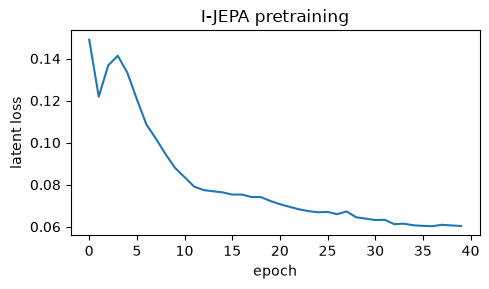

In [7]:
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1.5e-3, weight_decay=.05)
losses = []
for ep in range(EPOCHS):
    model.train(); t = time.time(); tot = 0; nb = 0
    for img, _ in train_loader:
        img = img.to(DEVICE, non_blocking=True)
        loss = model(img)
        opt.zero_grad(); loss.backward(); opt.step(); model.ema_update()
        tot += loss.item(); nb += 1
    losses.append(tot/nb)
    print(f"epoch {ep+1:2d}/{EPOCHS}  latent loss {tot/nb:.4f}  ({time.time()-t:.1f}s)")

plt.figure(figsize=(5,3)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("latent loss")
plt.title("I-JEPA pretraining"); plt.tight_layout(); plt.show()

## 7. Evaluate — a linear probe

The standard self-supervised test: **freeze** the encoder, mean-pool its patch tokens
into one vector per image, and train a single linear layer to classify. High accuracy
means the information is *linearly accessible* — the encoder organized it well. We compare
against a linear probe on **raw pixels**, a surprisingly strong baseline on CIFAR.

In [8]:
@torch.no_grad()
def encode_features(dataset):
    model.eval(); xs, ys = [], []
    for img, y in DataLoader(dataset, 512, num_workers=4):
        xs.append(model.context(img.to(DEVICE)).mean(1).cpu()); ys.append(y)  # frozen, mean-pooled
    return torch.cat(xs), torch.cat(ys)

def linear_probe(Xtr, Ytr, Xte, Yte, steps=1500):
    mu, sd = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True) + 1e-6
    Xtr, Xte = ((Xtr-mu)/sd).to(DEVICE), ((Xte-mu)/sd).to(DEVICE)
    Ytr, Yte = Ytr.to(DEVICE), Yte.to(DEVICE)
    clf = nn.Linear(Xtr.size(1), 10).to(DEVICE)
    o = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(steps):
        o.zero_grad(); F.cross_entropy(clf(Xtr), Ytr).backward(); o.step()
    return (clf(Xte).argmax(1) == Yte).float().mean().item()

Xtr, Ytr = encode_features(train_set); Xte, Yte = encode_features(test_set)
acc = linear_probe(Xtr, Ytr, Xte, Yte)

# raw-pixel baseline
Xr_tr = torch.tensor(train_set.data.reshape(len(train_set), -1)/255., dtype=torch.float32)
Xr_te = torch.tensor(test_set.data.reshape(len(test_set), -1)/255., dtype=torch.float32)
accb = linear_probe(Xr_tr, torch.tensor(train_set.targets), Xr_te, torch.tensor(test_set.targets), steps=500)

print(f"linear-probe accuracy (I-JEPA features): {acc*100:.1f}%")
print(f"linear-probe accuracy (raw pixels):      {accb*100:.1f}%")
print(f"random guessing:                         10.0%")

linear-probe accuracy (I-JEPA features): 56.7%
linear-probe accuracy (raw pixels):      40.2%
random guessing:                         10.0%


## 8. What we learned

- **The loss lives in embedding space.** There is no decoder and no pixel anywhere in the
  objective — the predictor outputs *vectors*, and we compare vectors.
- **The asymmetry is load-bearing.** The EMA teacher + stop-gradient give stable targets the
  student can't trivially game. Delete it and the encoder is free to collapse.
- **The frozen features are semantic.** Our linear probe beats the raw-pixel probe by a wide
  margin, even though pretraining never saw a label — exactly the claim "predict the
  representation, not the pixels" is making.
- **Scale honesty.** This is a tiny ViT trained for minutes; real I-JEPA is a ViT-H/14 on
  ImageNet (16 A100s, <72h). The *mechanism* here is the same; only the scale differs.

Next: `02_v-jepa_video_panning_cifar.ipynb` takes this into **space + time** — same recipe,
3D tubelets, run on short video clips (panning CIFAR-10 images, not moving MNIST — a clean
synthetic digit is linearly trivial, so SSL has nothing to add).